In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-200*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

import numpy, torch, scipy
print("NumPy :", numpy.__version__)   # → 1.26.4
print("Torch :", torch.__version__)   # → 2.2.2
print("SciPy :", scipy.__version__)   # → 1.15.2

2024-07-11 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']
NumPy : 2.2.4
Torch : 2.5.1
SciPy : 1.15.2


In [47]:

window_step_length = 6
window_size = 20
num_test_points = 200

horizon = 10 #3 is good
target_idx = 0



Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


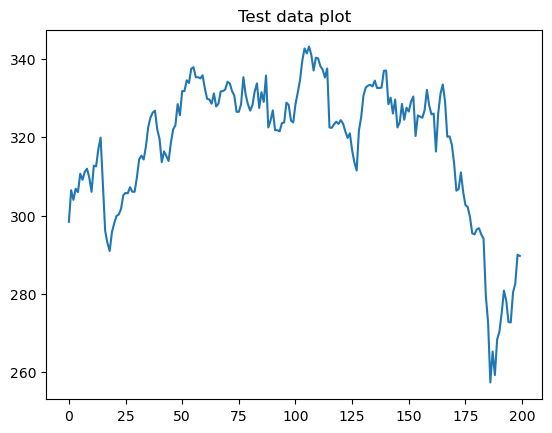

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.412449537198146
Normalized Benchmark: 0.0427479494221256


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

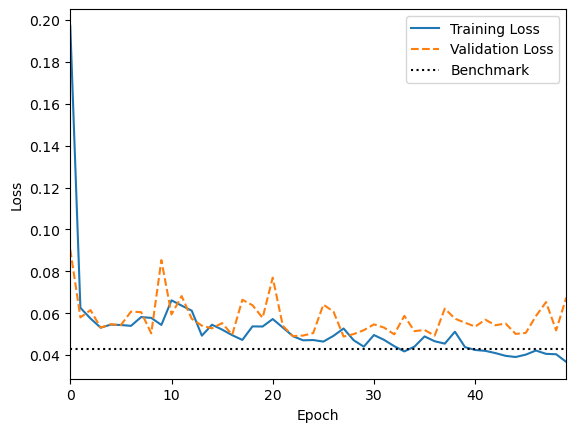

variance of returns for old data:  0.0029547387889741904
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(292.0483)
windows last2 price:  tensor(290.4776)
windows last3 price:  tensor(295.1897)
period from idx:  0  to idx  10
prediction at 10:  tensor(299.1024)
last price from test data:  292.0483093261719
real price 10 steps forward:  tensor(306.0862)
kelly weight:  {tensor(0.4444)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(306.0862)
windows last2 price:  tensor(309.7185)
windows last3 price:  tensor(311.9763)
period from idx:  10  to idx  20
prediction at 10:  tensor(300.8326)
last price from test data:  tensor(306.0862)
real price 10 steps forward:  tensor(298.0365)
kelly weight:  {tensor(-0.3158)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(298.0365)
windows last2 price:  tensor(295.7787)
windows last3 price:  tensor(290.9685)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


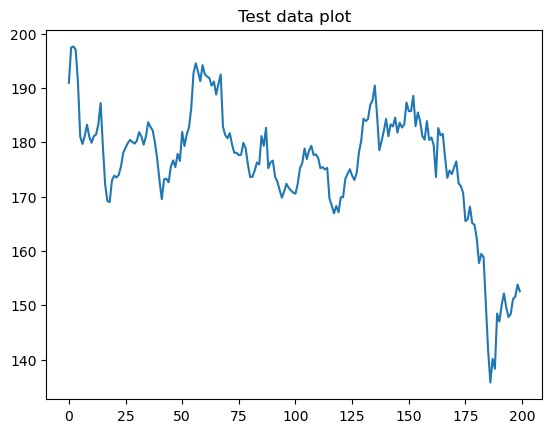

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.5763983381892581
Normalized Benchmark: 0.036150059115428235


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

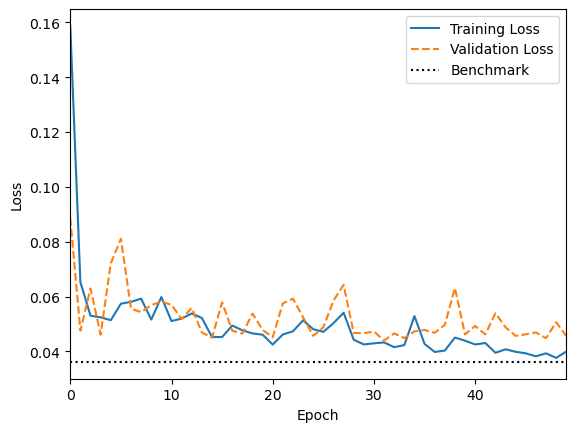

variance of returns for old data:  0.0035141657282645937
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(189.3760)
windows last2 price:  tensor(189.9653)
windows last3 price:  tensor(192.6665)
period from idx:  0  to idx  10
prediction at 10:  tensor(194.2675)
last price from test data:  189.37600708007807
real price 10 steps forward:  tensor(179.8974)
kelly weight:  {tensor(0.4357)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(179.8974)
windows last2 price:  tensor(181.0269)
windows last3 price:  tensor(183.2370)
period from idx:  10  to idx  20
prediction at 10:  tensor(188.2249)
last price from test data:  tensor(179.8974)
real price 10 steps forward:  tensor(173.8566)
kelly weight:  {tensor(0.7809)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(173.8566)
windows last2 price:  tensor(172.9726)
windows last3 price:  tensor(168.9945)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


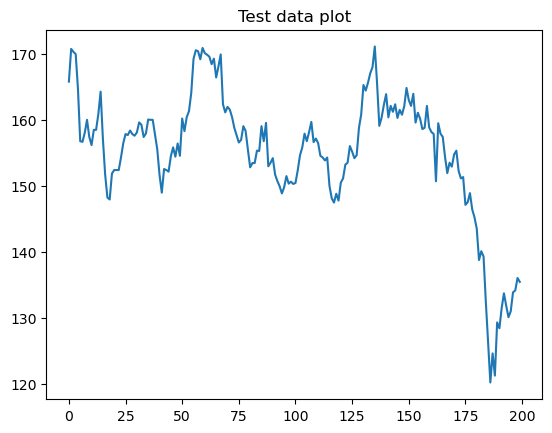

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.373612578404798
Normalized Benchmark: 0.036278573049014544


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

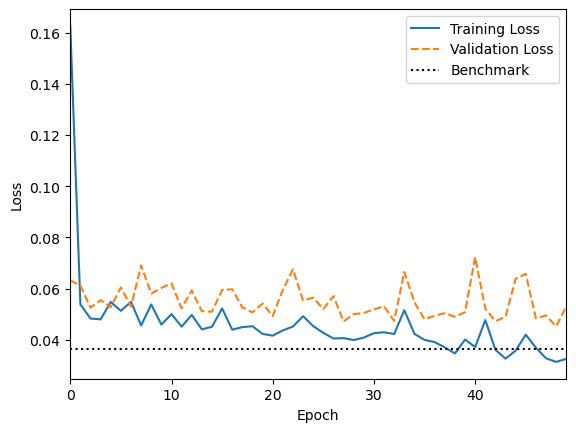

variance of returns for old data:  0.0036897997808150104
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(164.0397)
windows last2 price:  tensor(163.2556)
windows last3 price:  tensor(165.4120)
period from idx:  0  to idx  10
prediction at 10:  tensor(174.2993)
last price from test data:  164.0397491455078
real price 10 steps forward:  tensor(156.1490)
kelly weight:  {tensor(1.0296)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(156.1490)
windows last2 price:  tensor(157.3743)
windows last3 price:  tensor(159.9718)
period from idx:  10  to idx  20
prediction at 10:  tensor(162.7639)
last price from test data:  tensor(156.1490)
real price 10 steps forward:  tensor(152.3751)
kelly weight:  {tensor(0.6974)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(152.3751)
windows last2 price:  tensor(151.8360)
windows last3 price:  tensor(147.9151)
period from id

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


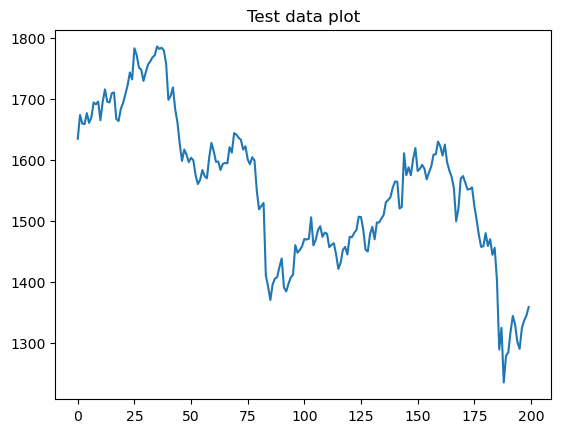

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 18.740559466713222
Normalized Benchmark: 0.053722932312346754


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

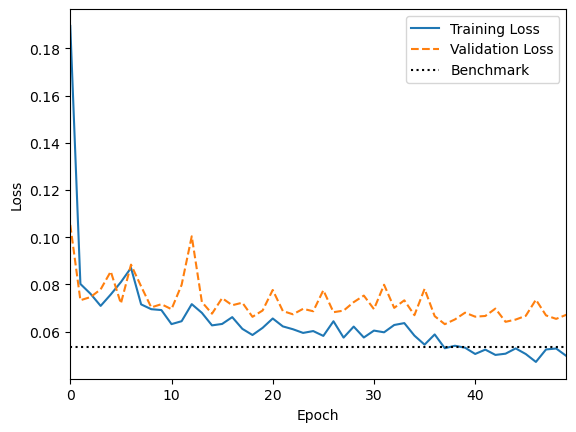

variance of returns for old data:  0.002300841757064683
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(1633.0167)
windows last2 price:  tensor(1613.5463)
windows last3 price:  tensor(1626.0273)
period from idx:  0  to idx  10
prediction at 10:  tensor(1660.5685)
last price from test data:  1633.0167236328125
real price 10 steps forward:  tensor(1664.9681)
kelly weight:  {tensor(0.3517)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(1664.9681)
windows last2 price:  tensor(1695.4218)
windows last3 price:  tensor(1690.9286)
period from idx:  10  to idx  20
prediction at 10:  tensor(1690.5670)
last price from test data:  tensor(1664.9681)
real price 10 steps forward:  tensor(1693.2057)
kelly weight:  {tensor(0.3205)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(1693.2057)
windows last2 price:  tensor(1683.4401)
windows last3 price:  tensor(1663.4705)


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


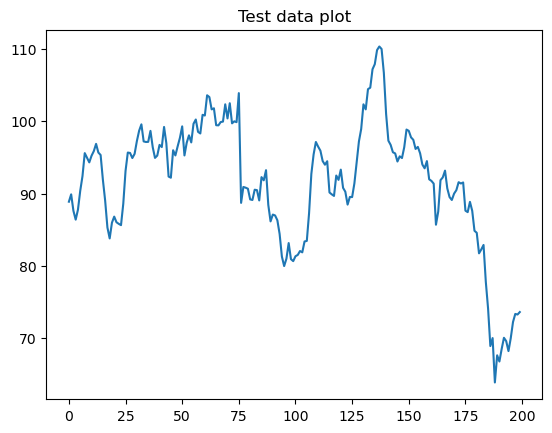

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.976100303488675
Normalized Benchmark: 0.07645889563115149


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

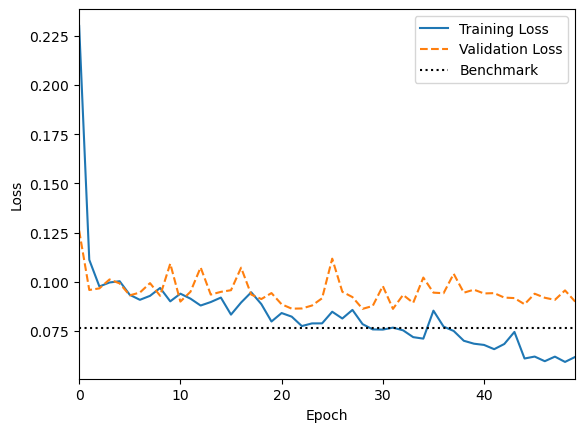

variance of returns for old data:  0.0044305914306802165
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(85.6200)
windows last2 price:  tensor(86.)
windows last3 price:  tensor(86.8200)
period from idx:  0  to idx  10
prediction at 10:  tensor(90.7038)
last price from test data:  85.62000274658203
real price 10 steps forward:  tensor(95.2400)
kelly weight:  {tensor(0.8920)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(95.2400)
windows last2 price:  tensor(94.3200)
windows last3 price:  tensor(94.9600)
period from idx:  10  to idx  20
prediction at 10:  tensor(97.3784)
last price from test data:  tensor(95.2400)
real price 10 steps forward:  tensor(86.8200)
kelly weight:  {tensor(0.3373)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(86.8200)
windows last2 price:  tensor(85.9800)
windows last3 price:  tensor(83.8000)
period from idx:  20  to idx  30

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


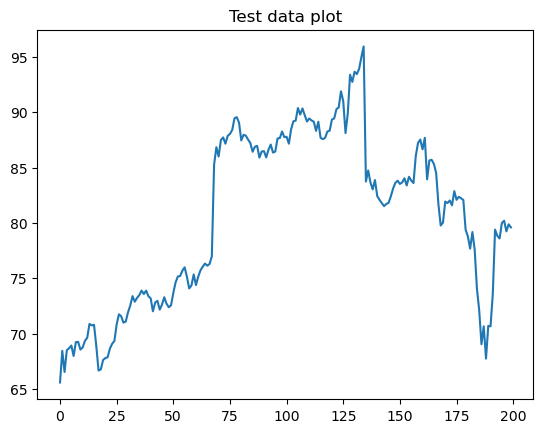

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 4.333448558954447
Normalized Benchmark: 0.06963271533099397


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

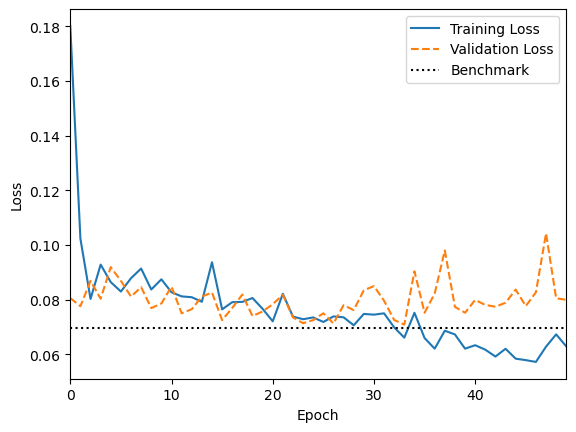

variance of returns for old data:  0.0070654732525931895
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(65.6036)
windows last2 price:  tensor(65.0822)
windows last3 price:  tensor(65.5650)
period from idx:  0  to idx  10
prediction at 10:  tensor(63.5722)
last price from test data:  65.60363006591797
real price 10 steps forward:  tensor(68.7515)
kelly weight:  {tensor(-0.3684)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(68.7515)
windows last2 price:  tensor(68.5584)
windows last3 price:  tensor(69.2536)
period from idx:  10  to idx  20
prediction at 10:  tensor(67.0106)
last price from test data:  tensor(68.7515)
real price 10 steps forward:  tensor(67.7859)
kelly weight:  {tensor(-0.3012)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(67.7859)
windows last2 price:  tensor(67.6121)
windows last3 price:  tensor(66.7624)
period from idx:  20  to i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


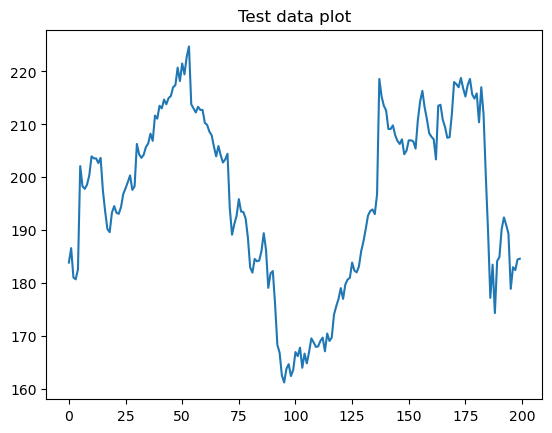

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 4.702481511370331
Normalized Benchmark: 0.061778270929145916


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

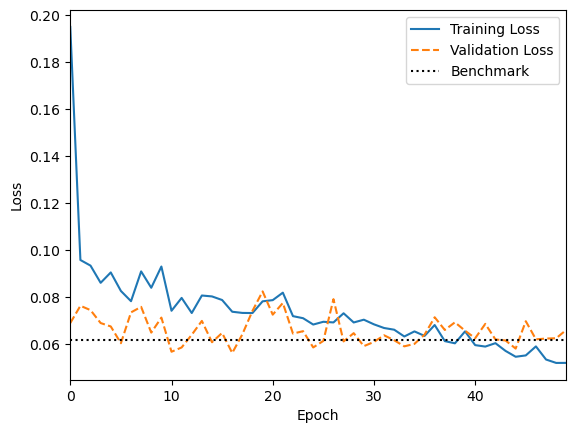

variance of returns for old data:  0.0037292502210577055
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(179.4850)
windows last2 price:  tensor(177.1939)
windows last3 price:  tensor(180.8499)
period from idx:  0  to idx  10
prediction at 10:  tensor(174.6641)
last price from test data:  179.48497009277344
real price 10 steps forward:  tensor(203.9557)
kelly weight:  {tensor(-0.4398)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(203.9557)
windows last2 price:  tensor(200.3485)
windows last3 price:  tensor(198.5936)
period from idx:  10  to idx  20
prediction at 10:  tensor(210.9780)
last price from test data:  tensor(203.9557)
real price 10 steps forward:  tensor(194.5477)
kelly weight:  {tensor(0.5638)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(194.5477)
windows last2 price:  tensor(193.3290)
windows last3 price:  tensor(189.6243)
period from 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


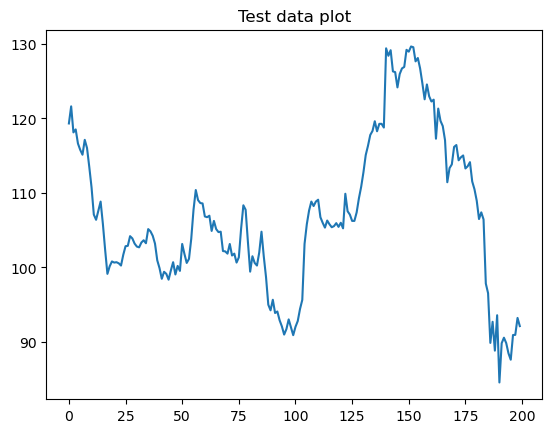

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.5990121527667354
Normalized Benchmark: 0.040460813519538036


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

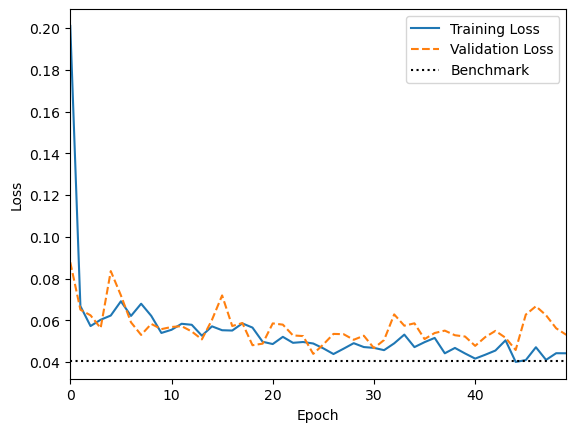

variance of returns for old data:  0.004407028898900936
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(117.2752)
windows last2 price:  tensor(117.2253)
windows last3 price:  tensor(121.1195)
period from idx:  0  to idx  10
prediction at 10:  tensor(125.2392)
last price from test data:  117.27518463134766
real price 10 steps forward:  tensor(110.7349)
kelly weight:  {tensor(1.0229)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(110.7349)
windows last2 price:  tensor(113.4808)
windows last3 price:  tensor(116.0270)
period from idx:  10  to idx  20
prediction at 10:  tensor(119.8198)
last price from test data:  tensor(110.7349)
real price 10 steps forward:  tensor(100.6500)
kelly weight:  {tensor(1.2358)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(100.6500)
windows last2 price:  tensor(100.7997)
windows last3 price:  tensor(100.1507)
period from id

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


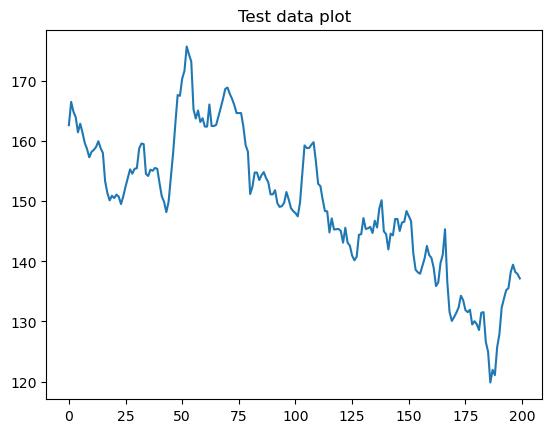

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 4.582352968853776
Normalized Benchmark: 0.08946879831295743


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

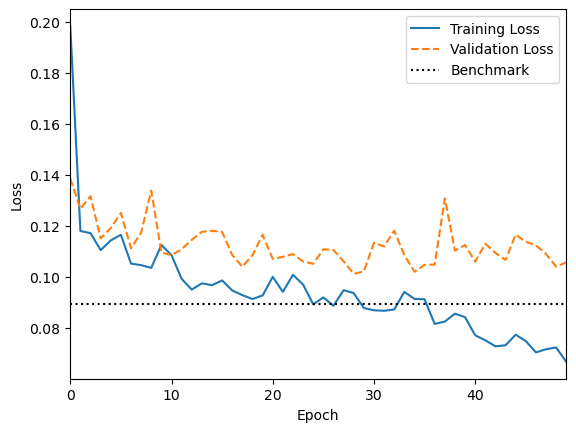

variance of returns for old data:  0.0035637669425487534
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(162.1386)
windows last2 price:  tensor(161.2309)
windows last3 price:  tensor(163.2851)
period from idx:  0  to idx  10
prediction at 10:  tensor(158.5878)
last price from test data:  162.1385955810547
real price 10 steps forward:  tensor(158.2213)
kelly weight:  {tensor(-0.3668)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(158.2213)
windows last2 price:  tensor(157.3136)
windows last3 price:  tensor(158.6990)
period from idx:  10  to idx  20
prediction at 10:  tensor(167.1370)
last price from test data:  tensor(158.2213)
real price 10 steps forward:  tensor(150.5300)
kelly weight:  {tensor(0.9439)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(150.5300)
windows last2 price:  tensor(150.9122)
windows last3 price:  tensor(150.1478)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


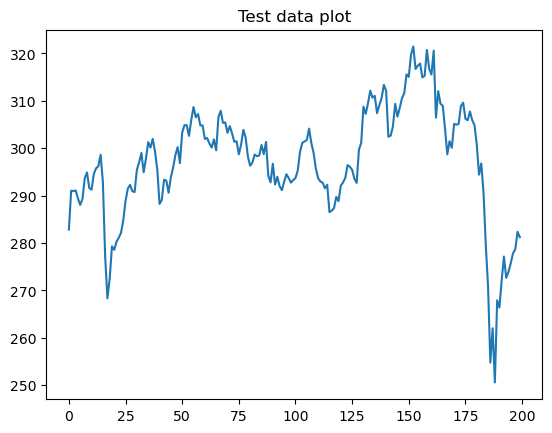

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.004110212921423
Normalized Benchmark: 0.03155797648966815


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

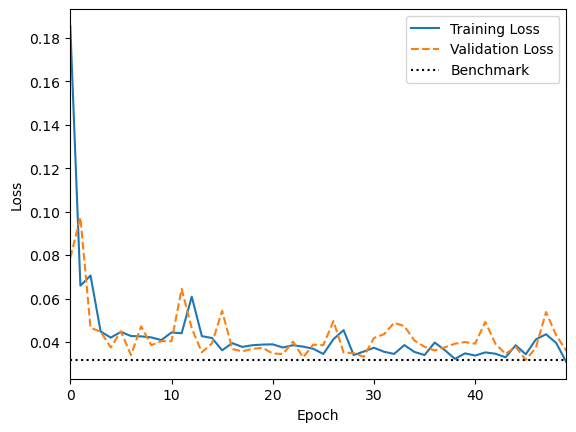

variance of returns for old data:  0.0022882775271258465
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(282.0987)
windows last2 price:  tensor(282.0496)
windows last3 price:  tensor(283.1799)
period from idx:  0  to idx  10
prediction at 10:  tensor(297.2867)
last price from test data:  282.0987243652344
real price 10 steps forward:  tensor(291.2399)
kelly weight:  {tensor(1.1255)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(291.2399)
windows last2 price:  tensor(291.5839)
windows last3 price:  tensor(294.8767)
period from idx:  10  to idx  20
prediction at 10:  tensor(300.1923)
last price from test data:  tensor(291.2399)
real price 10 steps forward:  tensor(278.5602)
kelly weight:  {tensor(0.6426)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(278.5602)
windows last2 price:  tensor(279.2974)
windows last3 price:  tensor(272.4169)
period from id

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


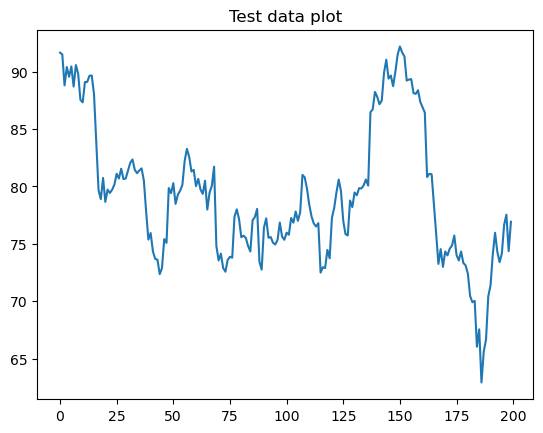

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 4.155551901939012
Normalized Benchmark: 0.05596290992000618


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

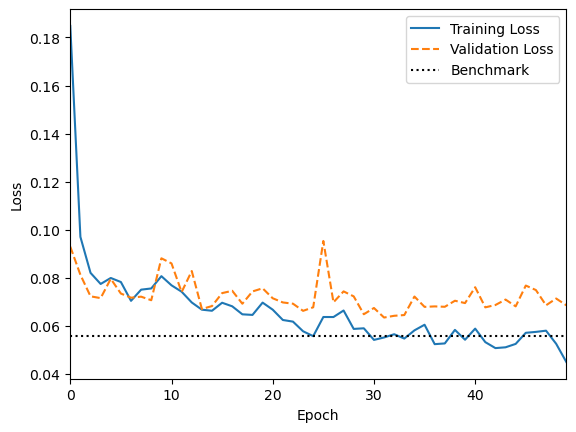

variance of returns for old data:  0.005702192835951572
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(89.5000)
windows last2 price:  tensor(91.2000)
windows last3 price:  tensor(86.9000)
period from idx:  0  to idx  10
prediction at 10:  tensor(95.7008)
last price from test data:  89.5
real price 10 steps forward:  tensor(87.3200)
kelly weight:  {tensor(0.9175)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(87.3200)
windows last2 price:  tensor(87.5400)
windows last3 price:  tensor(89.8300)
period from idx:  10  to idx  20
prediction at 10:  tensor(89.5465)
last price from test data:  tensor(87.3200)
real price 10 steps forward:  tensor(78.6500)
kelly weight:  {tensor(0.3377)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(78.6500)
windows last2 price:  tensor(80.7400)
windows last3 price:  tensor(78.8900)
period from idx:  20  to idx  30
predictio

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


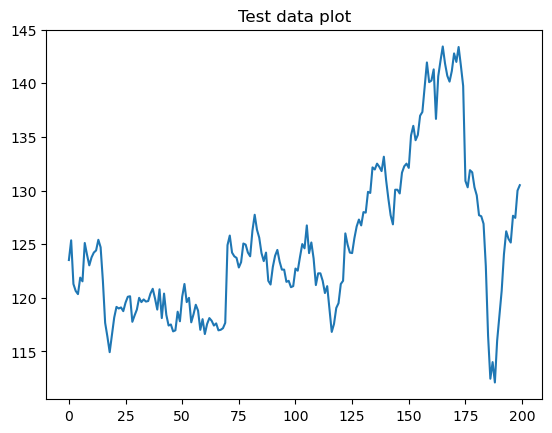

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.5395323185213807
Normalized Benchmark: 0.09911381857148846


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

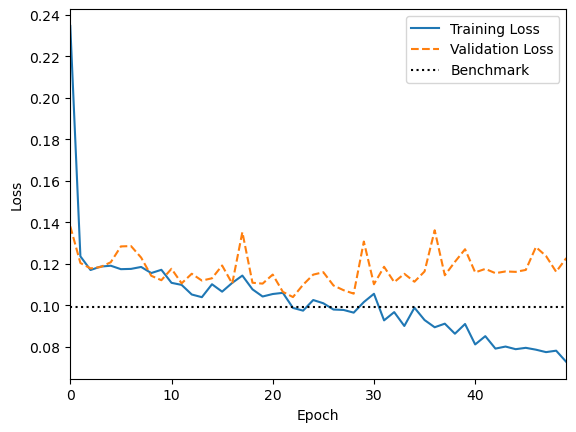

variance of returns for old data:  0.0031829986843373336
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(122.5259)
windows last2 price:  tensor(121.7809)
windows last3 price:  tensor(124.7112)
period from idx:  0  to idx  10
prediction at 10:  tensor(126.6756)
last price from test data:  122.52590942382812
real price 10 steps forward:  tensor(123.7676)
kelly weight:  {tensor(0.6003)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(123.7676)
windows last2 price:  tensor(123.0226)
windows last3 price:  tensor(124.0159)
period from idx:  10  to idx  20
prediction at 10:  tensor(122.9923)
last price from test data:  tensor(123.7676)
real price 10 steps forward:  tensor(118.1553)
kelly weight:  {tensor(-0.1110)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(118.1553)
windows last2 price:  tensor(116.5163)
windows last3 price:  tensor(114.9270)
period from 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


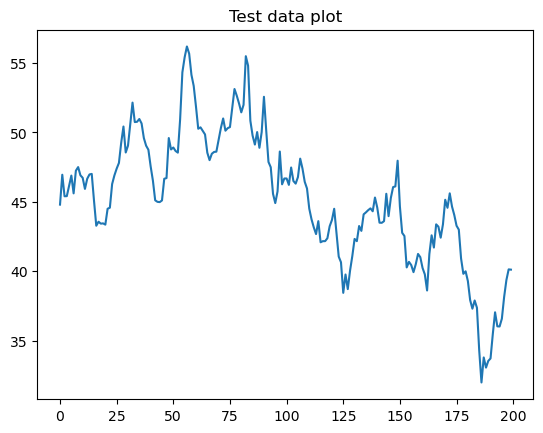

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.20252009495975
Normalized Benchmark: 0.039173964898229253


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

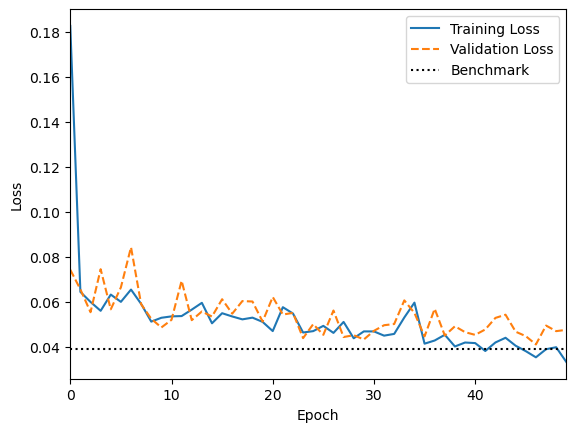

variance of returns for old data:  0.004095346090650751
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(43.3000)
windows last2 price:  tensor(44.7200)
windows last3 price:  tensor(46.5200)
period from idx:  0  to idx  10
prediction at 10:  tensor(45.3013)
last price from test data:  43.29999923706055
real price 10 steps forward:  tensor(46.7300)
kelly weight:  {tensor(0.7222)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(46.7300)
windows last2 price:  tensor(46.9100)
windows last3 price:  tensor(47.5000)
period from idx:  10  to idx  20
prediction at 10:  tensor(46.3497)
last price from test data:  tensor(46.7300)
real price 10 steps forward:  tensor(43.3600)
kelly weight:  {tensor(-0.1272)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(43.3600)
windows last2 price:  tensor(43.4500)
windows last3 price:  tensor(43.4300)
period from idx:  20  to idx

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


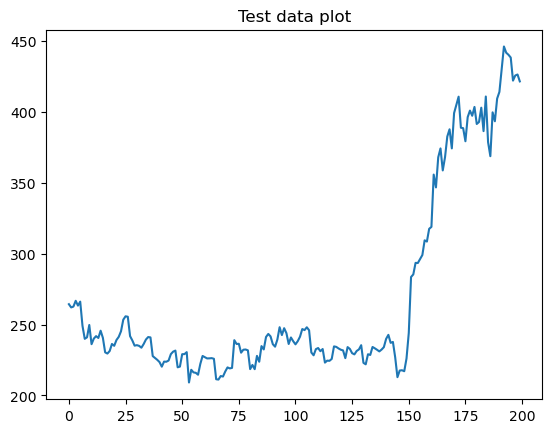

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.1087037120486176
Normalized Benchmark: 0.05459048730956581


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

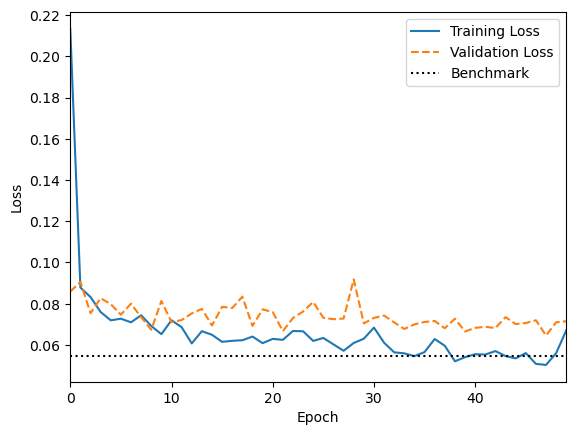

variance of returns for old data:  0.004298371493637463
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(264.1200)
windows last2 price:  tensor(255.4718)
windows last3 price:  tensor(255.2729)
period from idx:  0  to idx  10
prediction at 10:  tensor(287.5101)
last price from test data:  264.1200256347656
real price 10 steps forward:  tensor(236.1374)
kelly weight:  {tensor(1.3508)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(236.1374)
windows last2 price:  tensor(249.6565)
windows last3 price:  tensor(240.9586)
period from idx:  10  to idx  20
prediction at 10:  tensor(261.8874)
last price from test data:  tensor(236.1374)
real price 10 steps forward:  tensor(234.9942)
kelly weight:  {tensor(1.6633)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(234.9942)
windows last2 price:  tensor(236.2865)
windows last3 price:  tensor(231.3163)
period from idx

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


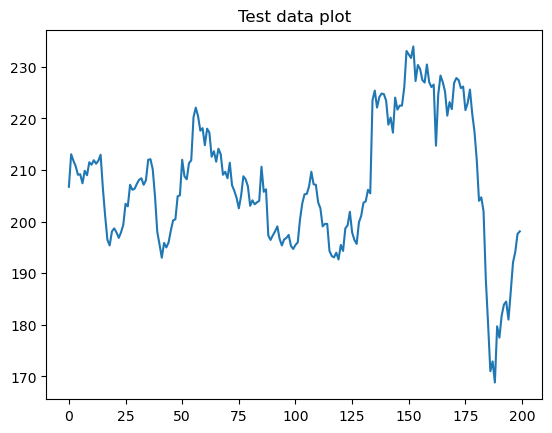

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.507966126947946
Normalized Benchmark: 0.0612489402816452


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

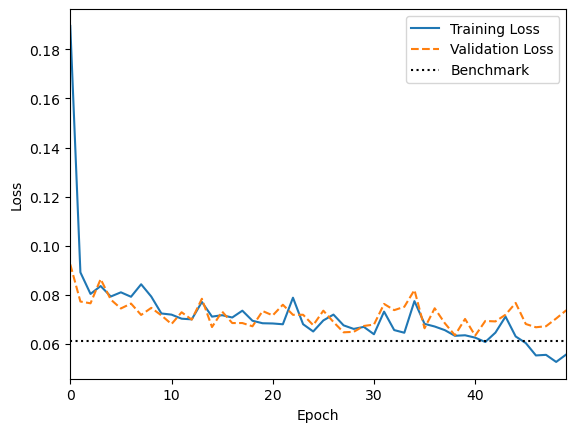

variance of returns for old data:  0.0034149838301453274
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(204.5199)
windows last2 price:  tensor(203.7426)
windows last3 price:  tensor(207.4347)
period from idx:  0  to idx  10
prediction at 10:  tensor(208.9755)
last price from test data:  204.5198974609375
real price 10 steps forward:  tensor(211.0295)
kelly weight:  {tensor(0.3728)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(211.0295)
windows last2 price:  tensor(211.5154)
windows last3 price:  tensor(208.9892)
period from idx:  10  to idx  20
prediction at 10:  tensor(210.1148)
last price from test data:  tensor(211.0295)
real price 10 steps forward:  tensor(198.6904)
kelly weight:  {tensor(-0.0742)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(198.6904)
windows last2 price:  tensor(198.1074)
windows last3 price:  tensor(195.3869)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


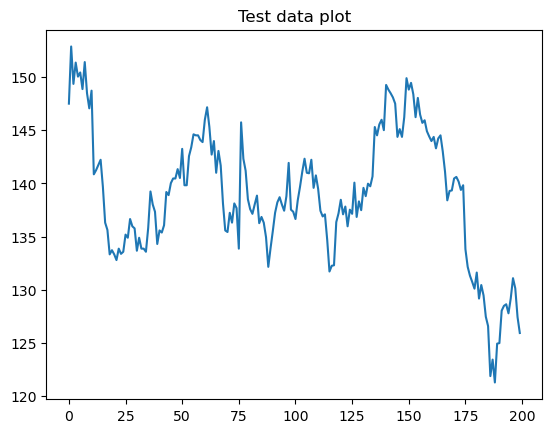

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.593551863632119
Normalized Benchmark: 0.03150732706079381


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

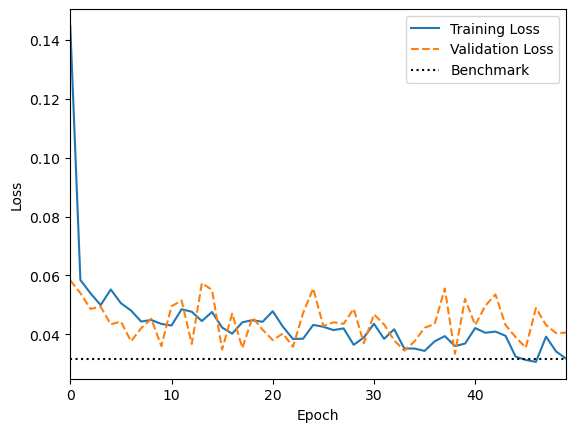

variance of returns for old data:  0.003303495667165457
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(149.4583)
windows last2 price:  tensor(148.9211)
windows last3 price:  tensor(148.7257)
period from idx:  0  to idx  10
prediction at 10:  tensor(148.2632)
last price from test data:  149.45834350585938
real price 10 steps forward:  tensor(148.7257)
kelly weight:  {tensor(-0.1391)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(148.7257)
windows last2 price:  tensor(147.0650)
windows last3 price:  tensor(148.4815)
period from idx:  10  to idx  20
prediction at 10:  tensor(146.5027)
last price from test data:  tensor(148.7257)
real price 10 steps forward:  tensor(133.3403)
kelly weight:  {tensor(-0.2601)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(133.3403)
windows last2 price:  tensor(133.7310)
windows last3 price:  tensor(133.3403)
period from 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


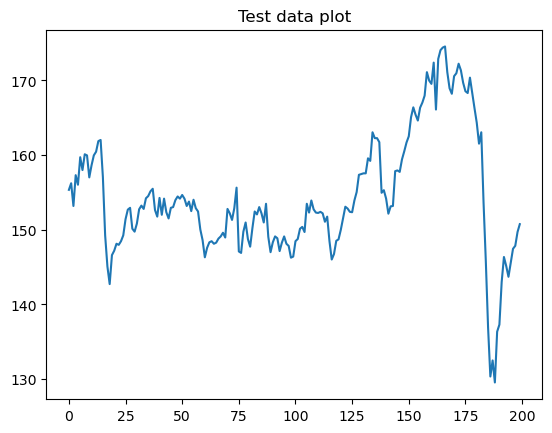

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.8201728160197859
Normalized Benchmark: 0.059726598106508315


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

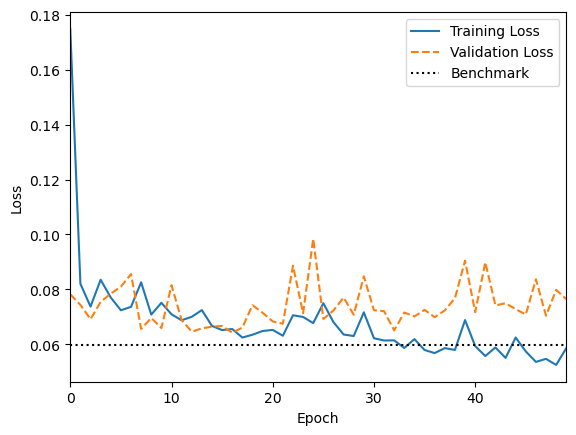

variance of returns for old data:  0.00393064166254563
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(151.2177)
windows last2 price:  tensor(150.2849)
windows last3 price:  tensor(151.6596)
period from idx:  0  to idx  10
prediction at 10:  tensor(156.0990)
last price from test data:  151.21771240234375
real price 10 steps forward:  tensor(158.6313)
kelly weight:  {tensor(0.5149)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(158.6313)
windows last2 price:  tensor(157.0111)
windows last3 price:  tensor(159.9569)
period from idx:  10  to idx  20
prediction at 10:  tensor(160.8622)
last price from test data:  tensor(158.6313)
real price 10 steps forward:  tensor(147.1918)
kelly weight:  {tensor(0.2243)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(147.1918)
windows last2 price:  tensor(146.6026)
windows last3 price:  tensor(142.7240)
period from idx

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


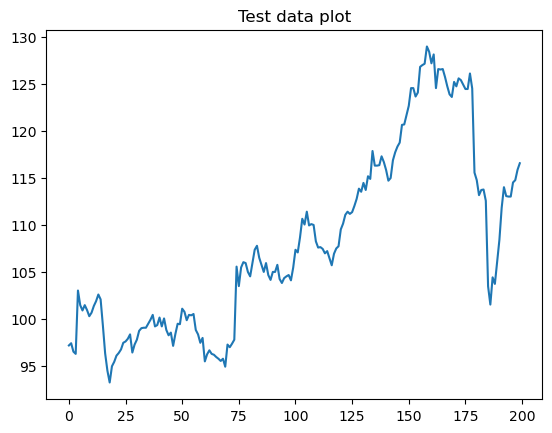

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.6559770102269382
Normalized Benchmark: 0.06517811387969312


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

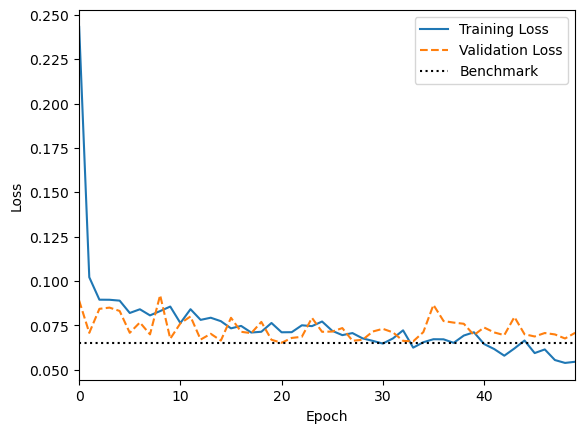

variance of returns for old data:  0.0023980848431864447
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(95.8744)
windows last2 price:  tensor(94.3182)
windows last3 price:  tensor(95.2142)
period from idx:  0  to idx  10
prediction at 10:  tensor(97.6725)
last price from test data:  95.87443542480467
real price 10 steps forward:  tensor(100.6375)
kelly weight:  {tensor(0.3830)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(100.6375)
windows last2 price:  tensor(100.2602)
windows last3 price:  tensor(100.9205)
period from idx:  10  to idx  20
prediction at 10:  tensor(99.5537)
last price from test data:  tensor(100.6375)
real price 10 steps forward:  tensor(95.4028)
kelly weight:  {tensor(-0.2199)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(95.4028)
windows last2 price:  tensor(94.9313)
windows last3 price:  tensor(93.2052)
period from idx:  20  

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


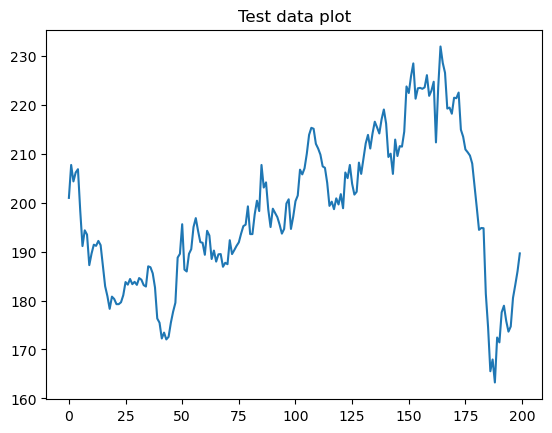

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 4.086314168894054
Normalized Benchmark: 0.07884507104823359


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

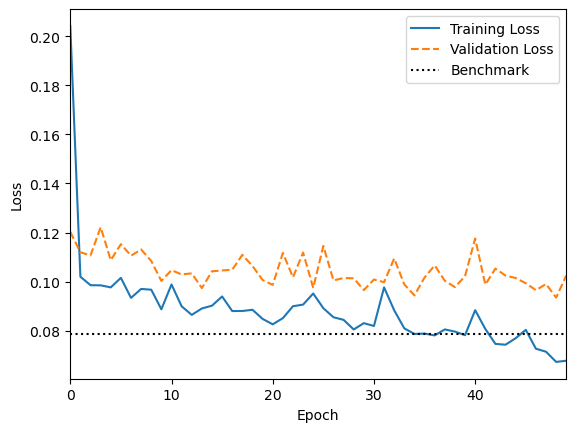

variance of returns for old data:  0.003404715676663535
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(198.6008)
windows last2 price:  tensor(198.4085)
windows last3 price:  tensor(204.7560)
period from idx:  0  to idx  10
prediction at 10:  tensor(202.5757)
last price from test data:  198.60081481933597
real price 10 steps forward:  tensor(189.6085)
kelly weight:  {tensor(0.3430)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(189.6085)
windows last2 price:  tensor(187.2522)
windows last3 price:  tensor(193.5036)
period from idx:  10  to idx  20
prediction at 10:  tensor(197.5047)
last price from test data:  tensor(189.6085)
real price 10 steps forward:  tensor(180.3276)
kelly weight:  {tensor(0.7137)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(180.3276)
windows last2 price:  tensor(180.8085)
windows last3 price:  tensor(178.3079)
period from id

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


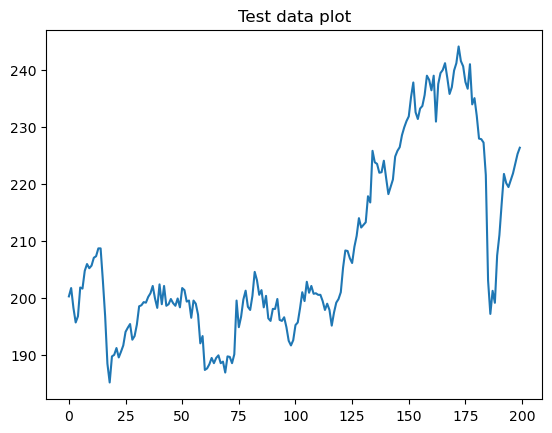

in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.86706645120669
Normalized Benchmark: 0.06448928764351618


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

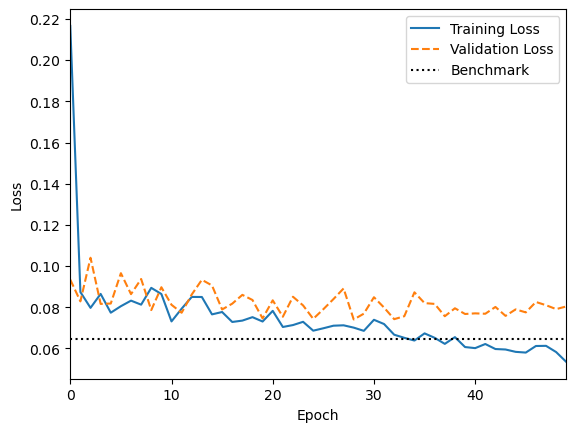

variance of returns for old data:  0.003981653594456605
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(196.3808)
windows last2 price:  tensor(193.4525)
windows last3 price:  tensor(197.4790)
period from idx:  0  to idx  10
prediction at 10:  tensor(201.0411)
last price from test data:  196.38082885742188
real price 10 steps forward:  tensor(205.6234)
kelly weight:  {tensor(0.3761)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(205.6234)
windows last2 price:  tensor(205.1658)
windows last3 price:  tensor(205.8979)
period from idx:  10  to idx  20
prediction at 10:  tensor(203.2412)
last price from test data:  tensor(205.6234)
real price 10 steps forward:  tensor(189.9751)
kelly weight:  {tensor(-0.1836)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(189.9751)
windows last2 price:  tensor(189.7006)
windows last3 price:  tensor(185.1251)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


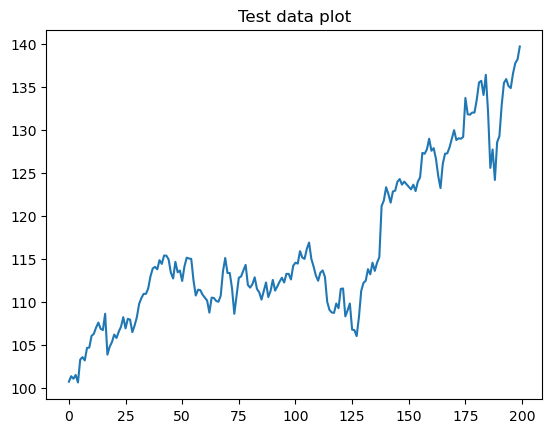

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.0952013436969894
Normalized Benchmark: 0.08957015110310239


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

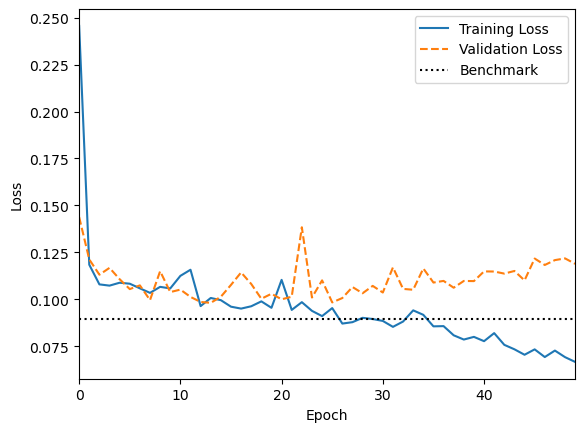

variance of returns for old data:  0.0041030533329287
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(100.3526)
windows last2 price:  tensor(99.0436)
windows last3 price:  tensor(98.8497)
period from idx:  0  to idx  10
prediction at 10:  tensor(99.3338)
last price from test data:  100.35257720947266
real price 10 steps forward:  tensor(106.0247)
kelly weight:  {tensor(-0.1585)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(106.0247)
windows last2 price:  tensor(104.6673)
windows last3 price:  tensor(104.6188)
period from idx:  10  to idx  20
prediction at 10:  tensor(105.2397)
last price from test data:  tensor(106.0247)
real price 10 steps forward:  tensor(106.1701)
kelly weight:  {tensor(-0.1156)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(106.1701)
windows last2 price:  tensor(105.2975)
windows last3 price:  tensor(104.7642)
period from idx: 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


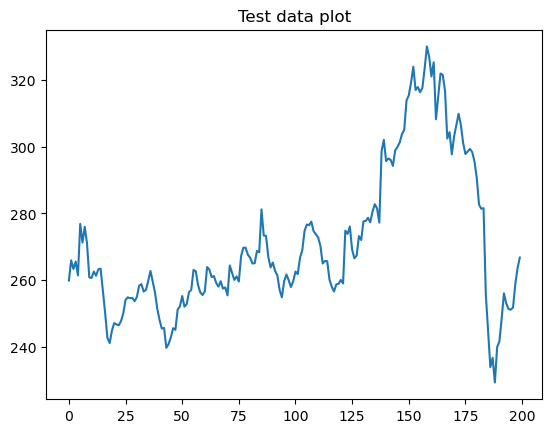

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


in sequences shape:  (1030, 20, 11)
targets shape:  (1030, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.1888771595580288
Normalized Benchmark: 0.05520878939949695


INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

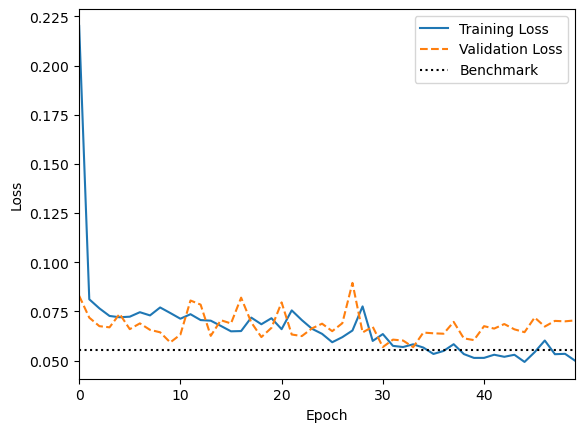

variance of returns for old data:  0.0038207006282715435
start window shape:  torch.Size([20, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(256.8238)
windows last2 price:  tensor(253.7389)
windows last3 price:  tensor(256.9202)
period from idx:  0  to idx  10
prediction at 10:  tensor(267.5983)
last price from test data:  256.8238220214844
real price 10 steps forward:  tensor(260.6800)
kelly weight:  {tensor(0.6787)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(260.6800)
windows last2 price:  tensor(260.8729)
windows last3 price:  tensor(270.9954)
period from idx:  10  to idx  20
prediction at 10:  tensor(268.5718)
last price from test data:  tensor(260.6800)
real price 10 steps forward:  tensor(247.1833)
kelly weight:  {tensor(0.4898)}
 
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(247.1833)
windows last2 price:  tensor(244.9660)
windows last3 price:  tensor(241.2062)
period from id

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


In [48]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from train.train_functions import plot_training
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 50
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=120, num_hidden_layers=5, out_dim=1, dropout=0.1, num_heads=24)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_lstm_v1
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)

(22, 200)
(200,)


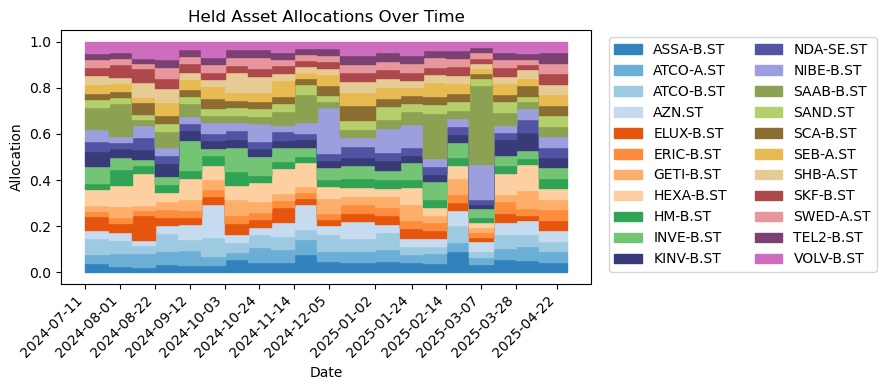

In [49]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

test_indices = df.index[-num_test_points*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

200
(22, 200)
(22, 200)
(200,)
Portfoliot final return:  1.044810135267119
Index final return 0.96005725629508


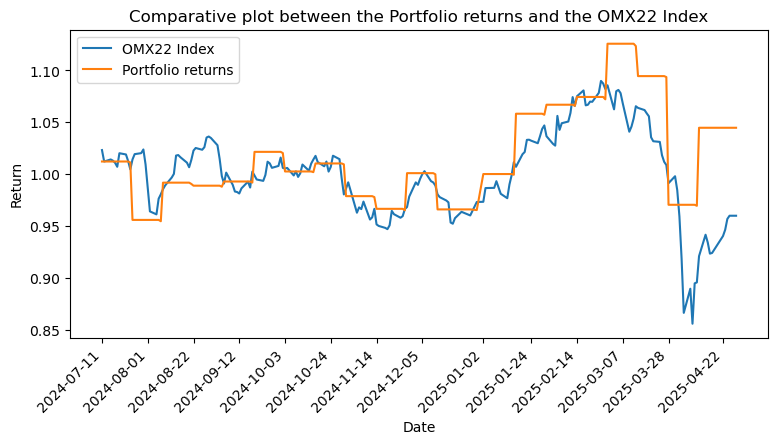

In [50]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt


print(len(test_indices))

returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
#print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values

index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
#print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



torch.Size([14, 20, 20])
Randomly selected samples: [12, 13, 10, 11]


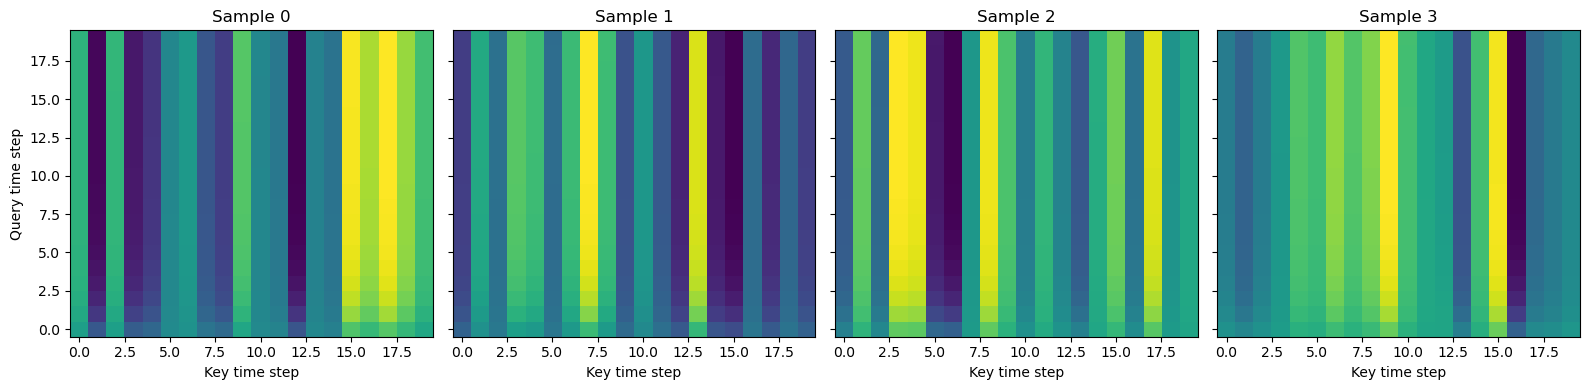

TypeError: Invalid shape (1, 20, 20) for image data

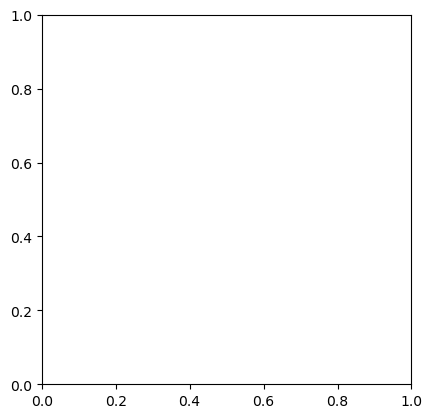

In [51]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()